# Structuring Scenarios for Investment

Monte Carlo simulation: per-stock vol (lognormal, mean 25%), turnover (beta, mean 17%),
pairwise correlation (ρ=0.35), single-factor model. Charts saved to `output/`.

In [1]:
import os, sys, numpy as np, pandas as pd
import matplotlib
IN_JUPYTER = 'ipykernel' in sys.modules
if not IN_JUPYTER:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt, matplotlib.ticker as mticker

os.makedirs('output', exist_ok=True)
try:
    import seaborn as sns
    sns.set_style('whitegrid')
    sns.set_context('notebook', font_scale=1.1)
except ImportError:
    plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': True, 'legend.fancybox': False,
    'legend.edgecolor': '#cccccc',
})
rng = np.random.default_rng(42)

## Parameters

In [2]:
INITIAL      = 100_000
N_STOCKS     = 20
INIT_PER_STK = INITIAL / N_STOCKS
YEARS        = 10
N_SIMS       = 10_000

# Smaller sample for sensitivity sweeps — speed up dev, can increase for final
S_SIMS       = 1_000

CG_MEAN   = 0.06
DIV_YIELD = 0.03
CPI       = 0.025
CORP_RATE = 0.30
RHO       = 0.35

# Pty Ltd: 30% corp rate during accumulation. At retirement, profits are drawn
# down over multiple years keeping total income under ~$135k. Effective individual
# rate on distribution ≈ 32% (30% bracket + 2% Medicare). Franking credits offset
# most, leaving a ~2% net top-up.
R_DIST = 0.32

# Dividend franking: most ASX dividends are fully franked at 30%
FRANKING_PCT  = 0.80   # fraction of dividends that are fully franked
FRANKING_RATE = 0.30   # corporate tax rate embedded in franking credit

VOL_MEDIAN = 0.22    # empirical ASX large/mid-cap
VOL_SIGMA  = 0.20    # lognormal dispersion
TURNOVER_A = 2       # beta(2,6) → mean ~25%
TURNOVER_B = 6
MAX_TURNOVER = 0.50

ARCHETYPES = {
    '1: $18,200 (2%)':   {'mr': 0.02},
    '2: $45,000 (18%)':  {'mr': 0.18},
    '3: $135,000 (32%)': {'mr': 0.32},
    '4: $190,000 (47%)': {'mr': 0.47},
}
SCENARIOS = ['Pre-Budget', 'Post-Budget', 'Pty Ltd']
COLS = ['#2e86c1', '#e74c3c', '#27ae60']

## Pre-generate shared data

In [3]:
# Per-stock volatilities: lognormal (right-skewed, matches empirical)
stock_vols = rng.lognormal(mean=np.log(VOL_MEDIAN), sigma=VOL_SIGMA,
                            size=(N_SIMS, N_STOCKS))
stock_vols = np.clip(stock_vols, 0.08, 0.60)
print(f"Vol: median {np.median(stock_vols)*100:.0f}%, "
      f"mean {stock_vols.mean()*100:.0f}%, "
      f"range [{stock_vols.min()*100:.0f}-{stock_vols.max()*100:.0f}]%")

# Log-return means per stock: ensure E[exp(r)] = 1 + CG_MEAN
mu_per_stock = np.log(1 + CG_MEAN) - 0.5 * stock_vols**2

# Single-factor model for correlated returns
market_shocks = rng.normal(0, 1, (N_SIMS, 1, YEARS))
idio_shocks   = rng.normal(0, 1, (N_SIMS, N_STOCKS, YEARS))
corr_logrets  = (np.sqrt(RHO) * market_shocks +
                 np.sqrt(1 - RHO) * idio_shocks)
# Scale by target vol and add mean
log_rets = mu_per_stock[:, :, None] + stock_vols[:, :, None] * corr_logrets
price_mults = np.exp(log_rets)

# Verify pairwise correlation
sample_corr = np.corrcoef(log_rets[0, :, :])  # 20 stocks x 10 yrs → 20x20 corr matrix
if sample_corr.ndim > 1:
    off_diag = sample_corr[~np.eye(N_STOCKS, dtype=bool)]
    print(f"Pairwise correlation (target {RHO}): mean {off_diag.mean():.3f}, "
          f"range [{off_diag.min():.3f}, {off_diag.max():.3f}]")
else:
    print(f"Pairwise correlation: single value {sample_corr}")

# Turnover: beta distribution, same shape for all sims/years
turnover_rates = rng.beta(TURNOVER_A, TURNOVER_B,
                           size=(N_SIMS, YEARS - 1))
n_sell = (turnover_rates * N_STOCKS).astype(int)
n_sell = np.clip(n_sell, 0, int(N_STOCKS * MAX_TURNOVER))
print(f"Turnover: mean {turnover_rates.mean()*100:.1f}%, "
      f"median {np.median(turnover_rates)*100:.1f}%, "
      f"P90 {np.percentile(turnover_rates,90)*100:.0f}%, "
      f"max {np.max(turnover_rates)*100:.0f}%")

# Pre-generate sell indices per (sim, year)
sell_idx_all = {}
for yr in range(YEARS - 1):
    max_ns = n_sell[:, yr].max()
    idx = np.full((N_SIMS, max(max_ns, 1)), -1)
    for sim in range(N_SIMS):
        ns = n_sell[sim, yr]
        if ns > 0:
            idx[sim, :ns] = rng.choice(N_STOCKS, size=ns, replace=False)
    sell_idx_all[yr] = idx

px_10yr = np.prod(price_mults, axis=2)
print(f"Stocks with negative 10yr return: {(px_10yr < 1).mean():.1%}")
print(f"Mean losers per portfolio: {(px_10yr < 1).sum(axis=1).mean():.1f} of {N_STOCKS}")

Vol: median 22%, mean 22%, range [8-60]%
Pairwise correlation (target 0.35): mean 0.425, range [-0.327, 0.943]
Turnover: mean 25.0%, median 22.8%, P90 45%, max 93%


Stocks with negative 10yr return: 31.3%
Mean losers per portfolio: 6.3 of 20


## Simulation engine

In [4]:
def simulate(mr, scenario):
    values       = np.full((N_SIMS, N_STOCKS), INIT_PER_STK, dtype=float)
    cost_bases   = np.full((N_SIMS, N_STOCKS), INIT_PER_STK, dtype=float)
    cost_years   = np.zeros((N_SIMS, N_STOCKS), dtype=int)  # purchase year per position
    carry_fwd    = np.zeros(N_SIMS)
    cum_div_tax  = np.zeros(N_SIMS)
    cum_cgt      = np.zeros(N_SIMS)
    cum_franking = np.zeros(N_SIMS)
    cum_taxable  = np.zeros(N_SIMS)  # pre-tax capital gains realised
    pf_history   = np.zeros((N_SIMS, YEARS))
    cgt_history  = np.zeros((N_SIMS, YEARS))

    for yr in range(YEARS):
        is_final = (yr == YEARS - 1)

        values *= price_mults[:, :, yr]

        dividends     = values * DIV_YIELD
        franked_d     = dividends * FRANKING_PCT
        unfranked_d   = dividends * (1 - FRANKING_PCT)
        grossed_up    = franked_d / (1 - FRANKING_RATE)
        frank_credit  = grossed_up * FRANKING_RATE

        if scenario == 'Pty Ltd':
            div_tax = np.maximum(grossed_up * CORP_RATE - frank_credit, 0) + unfranked_d * CORP_RATE
        else:
            div_tax = grossed_up * mr - frank_credit + unfranked_d * mr
        after_tax_div = dividends - div_tax
        values     += after_tax_div
        cost_bases += after_tax_div
        cum_div_tax  += div_tax.sum(axis=1)
        if scenario == 'Pty Ltd':
            cum_franking += frank_credit.sum(axis=1) + div_tax.sum(axis=1)

        if is_final:
            sell_mask = np.ones((N_SIMS, N_STOCKS), dtype=bool)
        else:
            sell_mask = np.zeros((N_SIMS, N_STOCKS), dtype=bool)
            idx_arr = sell_idx_all[yr]
            for sim in range(N_SIMS):
                valid = idx_arr[sim][idx_arr[sim] >= 0]
                sell_mask[sim, valid] = True

        for sim in range(N_SIMS):
            mask = sell_mask[sim]
            g = values[sim, mask] - cost_bases[sim, mask]
            if not is_final and (np.abs(g) < 1e-10).all():
                continue

            if scenario == 'Pre-Budget':
                net = g.sum() - carry_fwd[sim]
                if net > 0:
                    cum_taxable[sim] += net
                    tax = net * 0.5 * mr
                    cum_cgt[sim] += tax; carry_fwd[sim] = 0
                    pos = np.maximum(g, 0); ps = pos.sum()
                    if ps > 0: values[sim, mask] -= tax * pos / ps
                    cost_bases[sim, mask] = values[sim, mask]
                    cost_years[sim, mask] = yr
                else:
                    carry_fwd[sim] = -net
                    cost_bases[sim, mask] = values[sim, mask]
                    cost_years[sim, mask] = yr

            elif scenario == 'Post-Budget':
                rate = max(mr, 0.30 + 0.02)  # 30% floor + 2% Medicare
                idx_cost = cost_bases[sim, mask] * (1 + CPI) ** (yr - cost_years[sim, mask])
                real_g = values[sim, mask] - idx_cost
                nom_g  = g
                real_gains = np.maximum(real_g, 0)
                nom_losses = np.maximum(-nom_g, 0)
                net = real_gains.sum() - nom_losses.sum() - carry_fwd[sim]
                if net > 0:
                    cum_taxable[sim] += net
                    tax = net * rate
                    cum_cgt[sim] += tax; carry_fwd[sim] = 0
                    pos_sum = real_gains.sum()
                    if pos_sum > 0:
                        # Allocate tax to real gainers only
                        values[sim, mask] = np.where(real_g > 0,
                            values[sim, mask] - tax * real_gains / pos_sum,
                            values[sim, mask])
                    cost_bases[sim, mask] = values[sim, mask]
                    cost_years[sim, mask] = yr
                else:
                    carry_fwd[sim] = -net
                    cost_bases[sim, mask] = values[sim, mask]
                    cost_years[sim, mask] = yr

            elif scenario == 'Pty Ltd':
                net = g.sum() - carry_fwd[sim]
                if net > 0:
                    cum_taxable[sim]     += net
                    tax = net * CORP_RATE
                    cum_cgt[sim]         += tax
                    cum_franking[sim]    += tax
                    carry_fwd[sim] = 0
                    pos = np.maximum(g, 0); ps = pos.sum()
                    if ps > 0: values[sim, mask] -= tax * pos / ps
                    cost_bases[sim, mask] = values[sim, mask]
                    cost_years[sim, mask] = yr
                else:
                    carry_fwd[sim] = -net
                    cost_bases[sim, mask] = values[sim, mask]
                    cost_years[sim, mask] = yr

        pf_history[:, yr]  = values.sum(axis=1)
        cgt_history[:, yr] = cum_cgt.copy()

    total_pf = values.sum(axis=1)

    if scenario == 'Pty Ltd':
        roc       = np.minimum(total_pf, INITIAL)
        dividend  = total_pf - roc
        max_frank = dividend * CORP_RATE / (1 - CORP_RATE)
        franking  = np.minimum(cum_franking, max_frank)
        grossed_up = dividend + franking
        ind_tax   = grossed_up * R_DIST
        net_tax   = ind_tax - franking
        final     = roc + dividend - net_tax
        total_tax = cum_div_tax + cum_cgt + np.maximum(net_tax, 0) - np.maximum(-net_tax, 0)
    else:
        final     = total_pf
        total_tax = cum_div_tax + cum_cgt

    return final, total_tax, total_pf, cum_cgt, cum_div_tax, cum_taxable, pf_history, cgt_history, total_pf

## Sensitivity helpers

In [5]:
# Shared state that simulate() depends on — save/restore for parameter sweep
_SHARED_GLOBALS = ['stock_vols', 'price_mults', 'n_sell', 'sell_idx_all',
                   'N_SIMS', 'YEARS', 'INIT_PER_STK']

def _save_globals():
    g = globals()
    return {k: g[k] for k in _SHARED_GLOBALS if k in g}

def _restore_globals(saved):
    for k, v in saved.items():
        globals()[k] = v

def _regenerate_shared(years, n_sims):
    """Regenerate stock_vols, price_mults, turnover_rates, sell_idx_all."""
    rng_local = np.random.default_rng(42)
    vols = rng_local.lognormal(np.log(VOL_MEDIAN), VOL_SIGMA, (n_sims, N_STOCKS))
    vols = np.clip(vols, 0.08, 0.60)
    mu = np.log(1 + CG_MEAN) - 0.5 * vols ** 2
    mkt = rng_local.normal(0, 1, (n_sims, 1, years))
    idio = rng_local.normal(0, 1, (n_sims, N_STOCKS, years))
    corr = np.sqrt(RHO) * mkt + np.sqrt(1 - RHO) * idio
    pm = np.exp(mu[:, :, None] + vols[:, :, None] * corr)
    tr = rng_local.beta(TURNOVER_A, TURNOVER_B, (n_sims, years - 1))
    ns = (tr * N_STOCKS).astype(int)
    ns = np.clip(ns, 0, int(N_STOCKS * MAX_TURNOVER))
    sell = {}
    for yr in range(years - 1):
        mx = ns[:, yr].max()
        idx = np.full((n_sims, max(mx, 1)), -1)
        for s in range(n_sims):
            if ns[s, yr] > 0:
                idx[s, :ns[s, yr]] = rng_local.choice(N_STOCKS, ns[s, yr], replace=False)
        sell[yr] = idx
    # Set module-level globals that simulate() reads
    g = globals()
    g['stock_vols'] = vols
    g['price_mults'] = pm
    g['n_sell'] = ns
    g['sell_idx_all'] = sell
    g['N_SIMS'] = n_sims
    g['YEARS'] = years
    g['INIT_PER_STK'] = INITIAL / N_STOCKS

## Run and cache

In [6]:
all_results = {}
for arch_label, arch in ARCHETYPES.items():
    mr = arch['mr']
    all_results[arch_label] = {}
    for sc in SCENARIOS:
        all_results[arch_label][sc] = simulate(mr, sc)
        print(f"  {arch_label} / {sc} done")

  1: $18,200 (2%) / Pre-Budget done


  1: $18,200 (2%) / Post-Budget done


  1: $18,200 (2%) / Pty Ltd done


  2: $45,000 (18%) / Pre-Budget done


  2: $45,000 (18%) / Post-Budget done


...

  3: $135,000 (32%) / Post-Budget done


  3: $135,000 (32%) / Pty Ltd done


  4: $190,000 (47%) / Pre-Budget done


  4: $190,000 (47%) / Post-Budget done


  4: $190,000 (47%) / Pty Ltd done


## 1. Summary Table

In [7]:
rows = []
for arch_label in ARCHETYPES:
    for sc in SCENARIOS:
        wealth, tax, pf, cgt, dvt, _, _, _, _ = all_results[arch_label][sc]
        nom_gain = np.maximum(pf - INITIAL, 1e-9)
        eff_cgt = cgt / nom_gain
        rows.append({
            'Archetype': arch_label, 'Scenario': sc,
            'Mean Wealth': f'${wealth.mean():,.0f}',
            'Median': f'${np.median(wealth):,.0f}',
            'P10': f'${np.percentile(wealth,10):,.0f}',
            'P90': f'${np.percentile(wealth,90):,.0f}',
            'Mean Tax': f'${tax.mean():,.0f}',
            'Mean CGT': f'${cgt.mean():,.0f}',
            'Eff CGT%': f'{np.median(eff_cgt)*100:.0f}%',
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

        Archetype    Scenario Mean Wealth   Median      P10      P90 Mean Tax Mean CGT Eff CGT%
  1: $18,200 (2%)  Pre-Budget    $263,426 $237,487 $138,017 $420,873 $-15,096   $1,040       1%
  1: $18,200 (2%) Post-Budget    $232,226 $218,044 $135,865 $345,547   $9,692  $25,133      16%
  1: $18,200 (2%)     Pty Ltd    $199,706 $187,110 $120,469 $294,259  $33,643  $27,937      25%
 2: $45,000 (18%)  Pre-Budget    $237,620 $216,468 $128,934 $372,880   $3,990   $8,922       6%
 2: $45,000 (18%) Post-Budget    $217,599 $204,557 $127,646 $323,237  $19,693  $24,475      18%
 2: $45,000 (18%)     Pty Ltd    $199,706 $187,110 $120,469 $294,259  $33,643  $27,937      25%
3: $135,000 (32%)  Pre-Budget    $216,706 $199,246 $121,485 $333,664  $19,278  $15,211      12%
3: $135,000 (32%) Post-Budget    $205,475 $193,338 $120,834 $304,899  $27,905  $23,915      20%
3: $135,000 (32%)     Pty Ltd    $199,706 $187,110 $120,469 $294,259  $33,643  $27,937      25%
4: $190,000 (47%)  Pre-Budget    $195,91

## 1b. 30-Year Comparison

Pty Ltd structures require long horizons — at 30 years the compounding
advantage of the 30% corporate rate becomes decisive.

In [8]:
r30_saved = _save_globals()
_regenerate_shared(30, S_SIMS)

print(f'\n{"Archetype":>22s} {"Pre-Budget":>12s} {"Post-Budget":>12s} {"Pty Ltd":>12s}')
print('-' * 64)
for arch_label, arch in ARCHETYPES.items():
    mr = arch['mr']
    vals = []
    for sc in SCENARIOS:
        r = simulate(mr, sc)
        vals.append(r[0].mean())
    print(f'{arch_label:>22s} ' + ' '.join(f'${v:>11,.0f}' for v in vals))

_restore_globals(r30_saved)


             Archetype   Pre-Budget  Post-Budget      Pty Ltd
----------------------------------------------------------------


       1: $18,200 (2%) $  1,751,380 $  1,274,676 $    814,534


      2: $45,000 (18%) $  1,302,159 $  1,047,921 $    814,534


     3: $135,000 (32%) $    998,835 $    881,663 $    814,534


     4: $190,000 (47%) $    746,799 $    614,514 $    814,534


## 2. Scenario Comparison (10yr)

In [9]:
print(f'\n{"Archetype":>22s} {"Pre-Budget":>12s} {"Post-Budget":>12s} {"Pty Ltd":>12s}')
print('-' * 64)
for arch_label, arch in ARCHETYPES.items():
    vals = []
    for sc in SCENARIOS:
        vals.append(all_results[arch_label][sc][0].mean())
    print(f'{arch_label:>22s} ' + ' '.join(f'${v:>11,.0f}' for v in vals))


             Archetype   Pre-Budget  Post-Budget      Pty Ltd
----------------------------------------------------------------
       1: $18,200 (2%) $    263,426 $    232,226 $    199,706
      2: $45,000 (18%) $    237,620 $    217,599 $    199,706
     3: $135,000 (32%) $    216,706 $    205,475 $    199,706
     4: $190,000 (47%) $    195,918 $    180,472 $    199,706


## 3. Portfolio Paths — 32% and 47% brackets

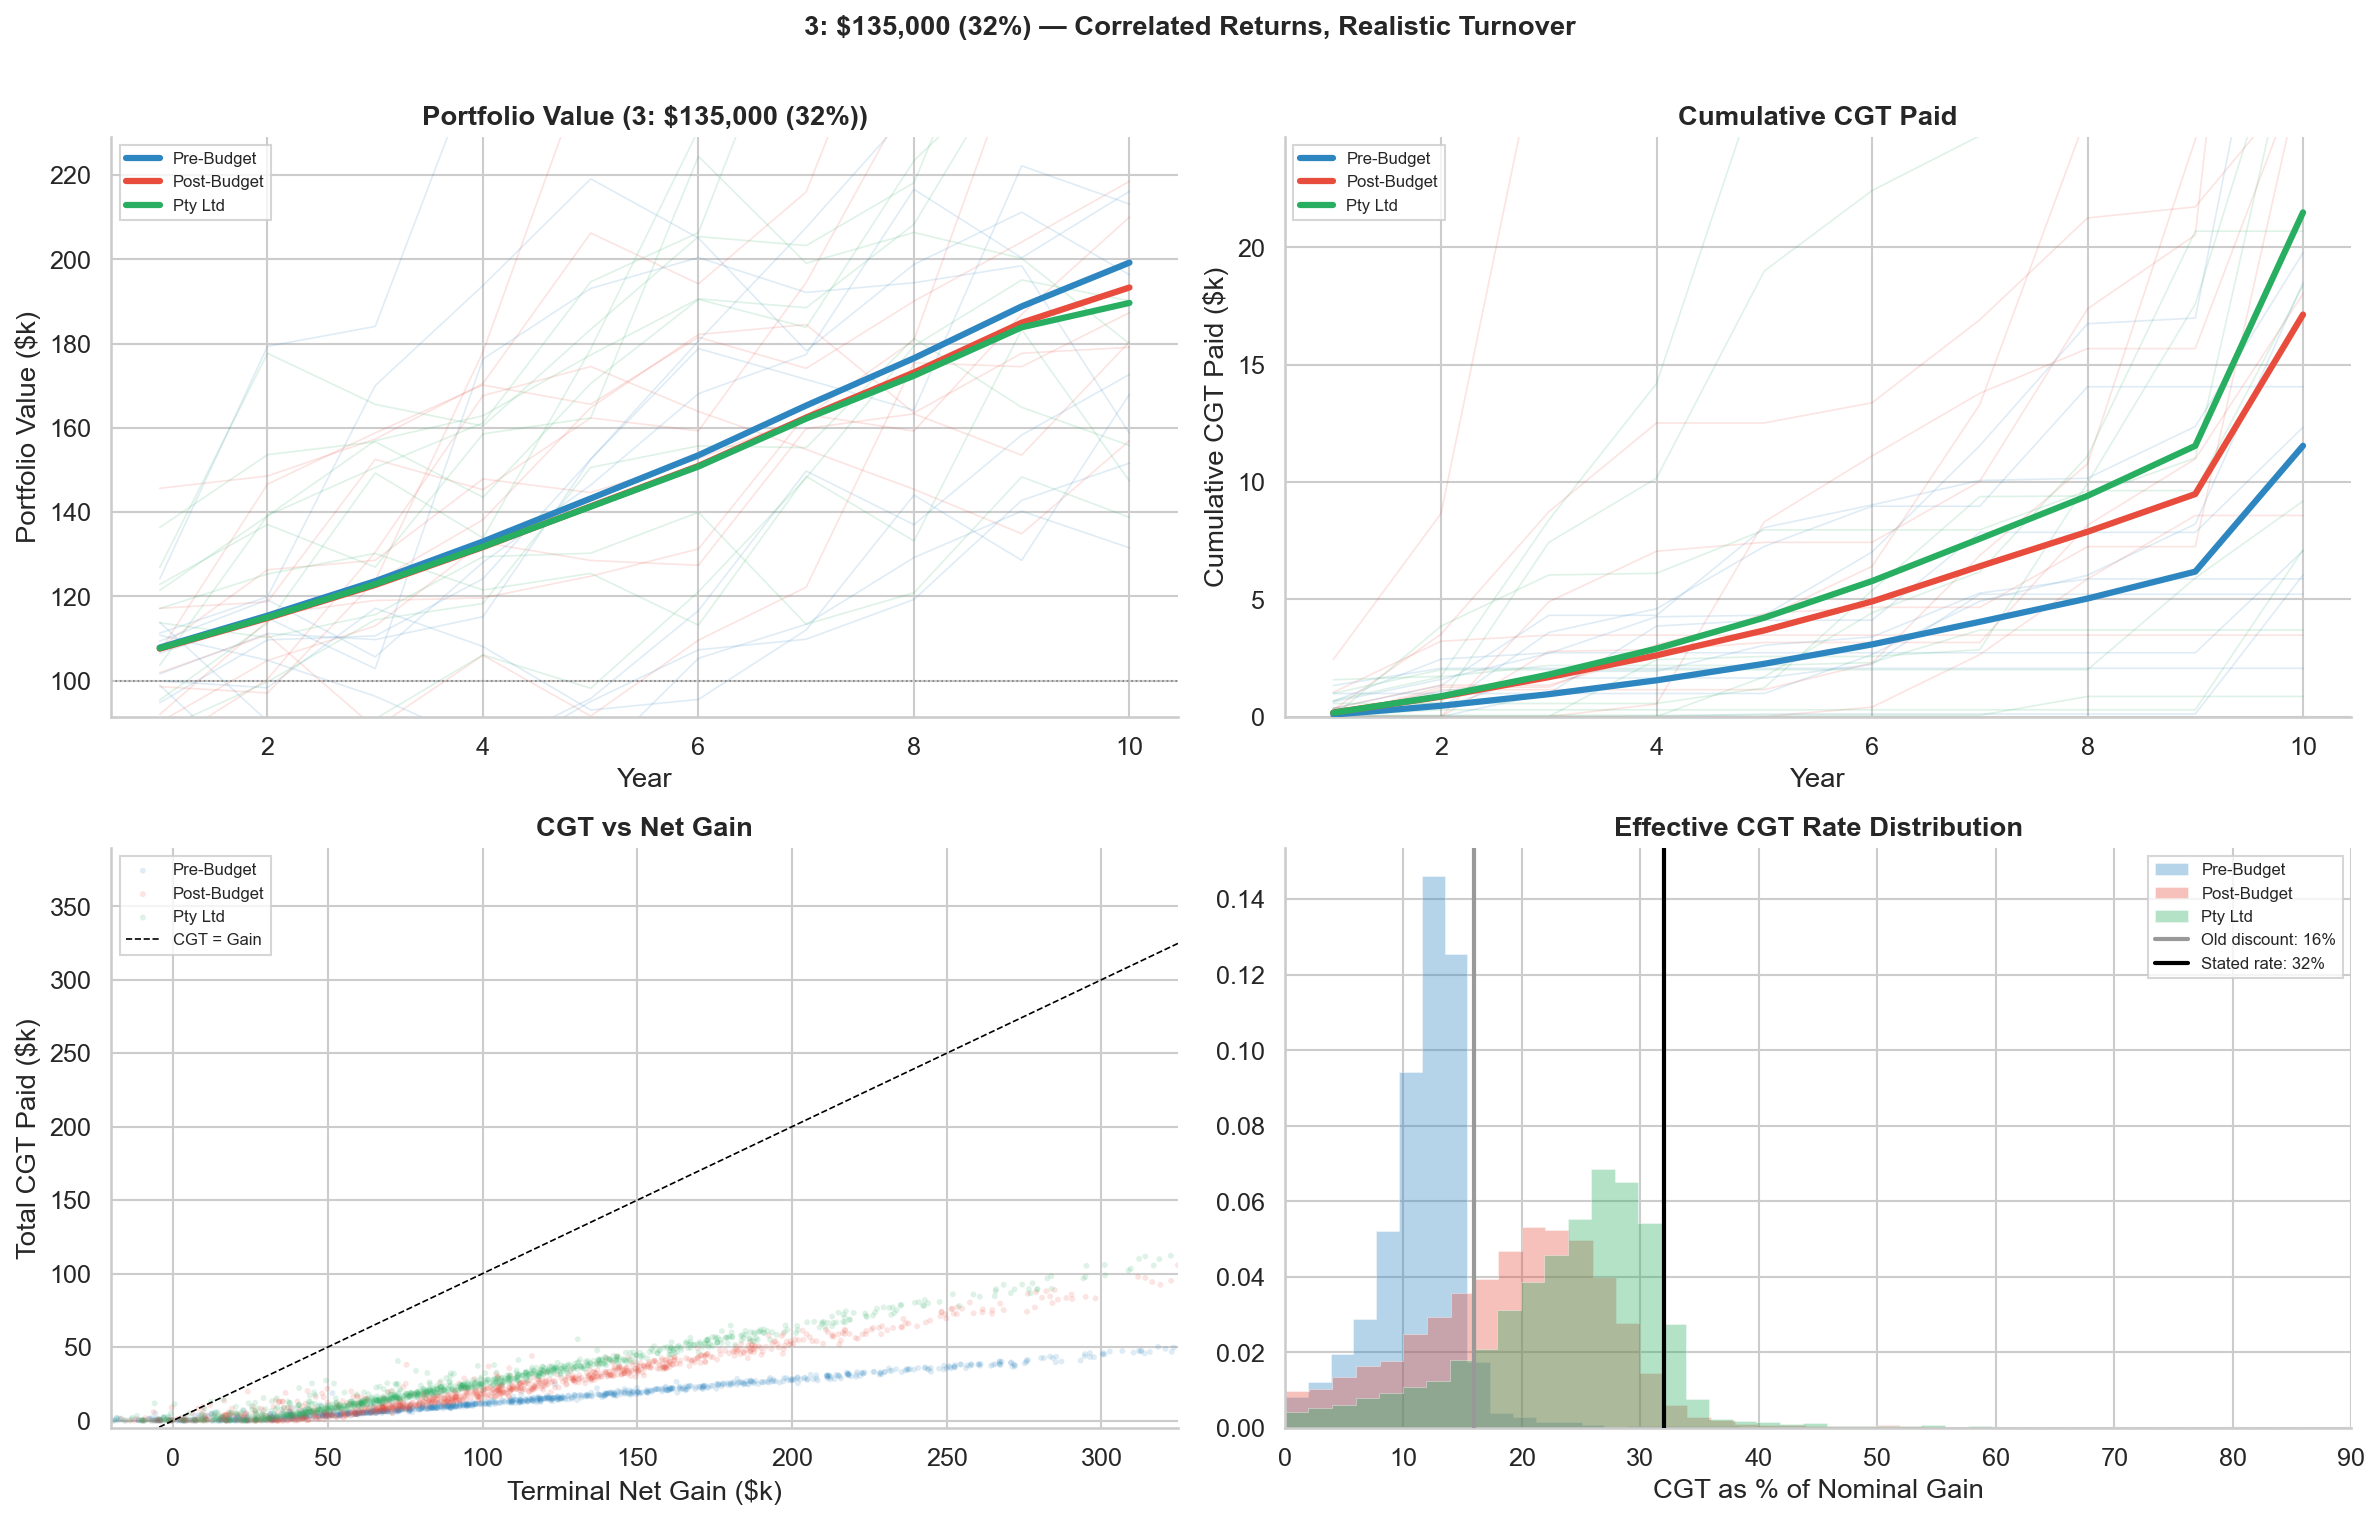

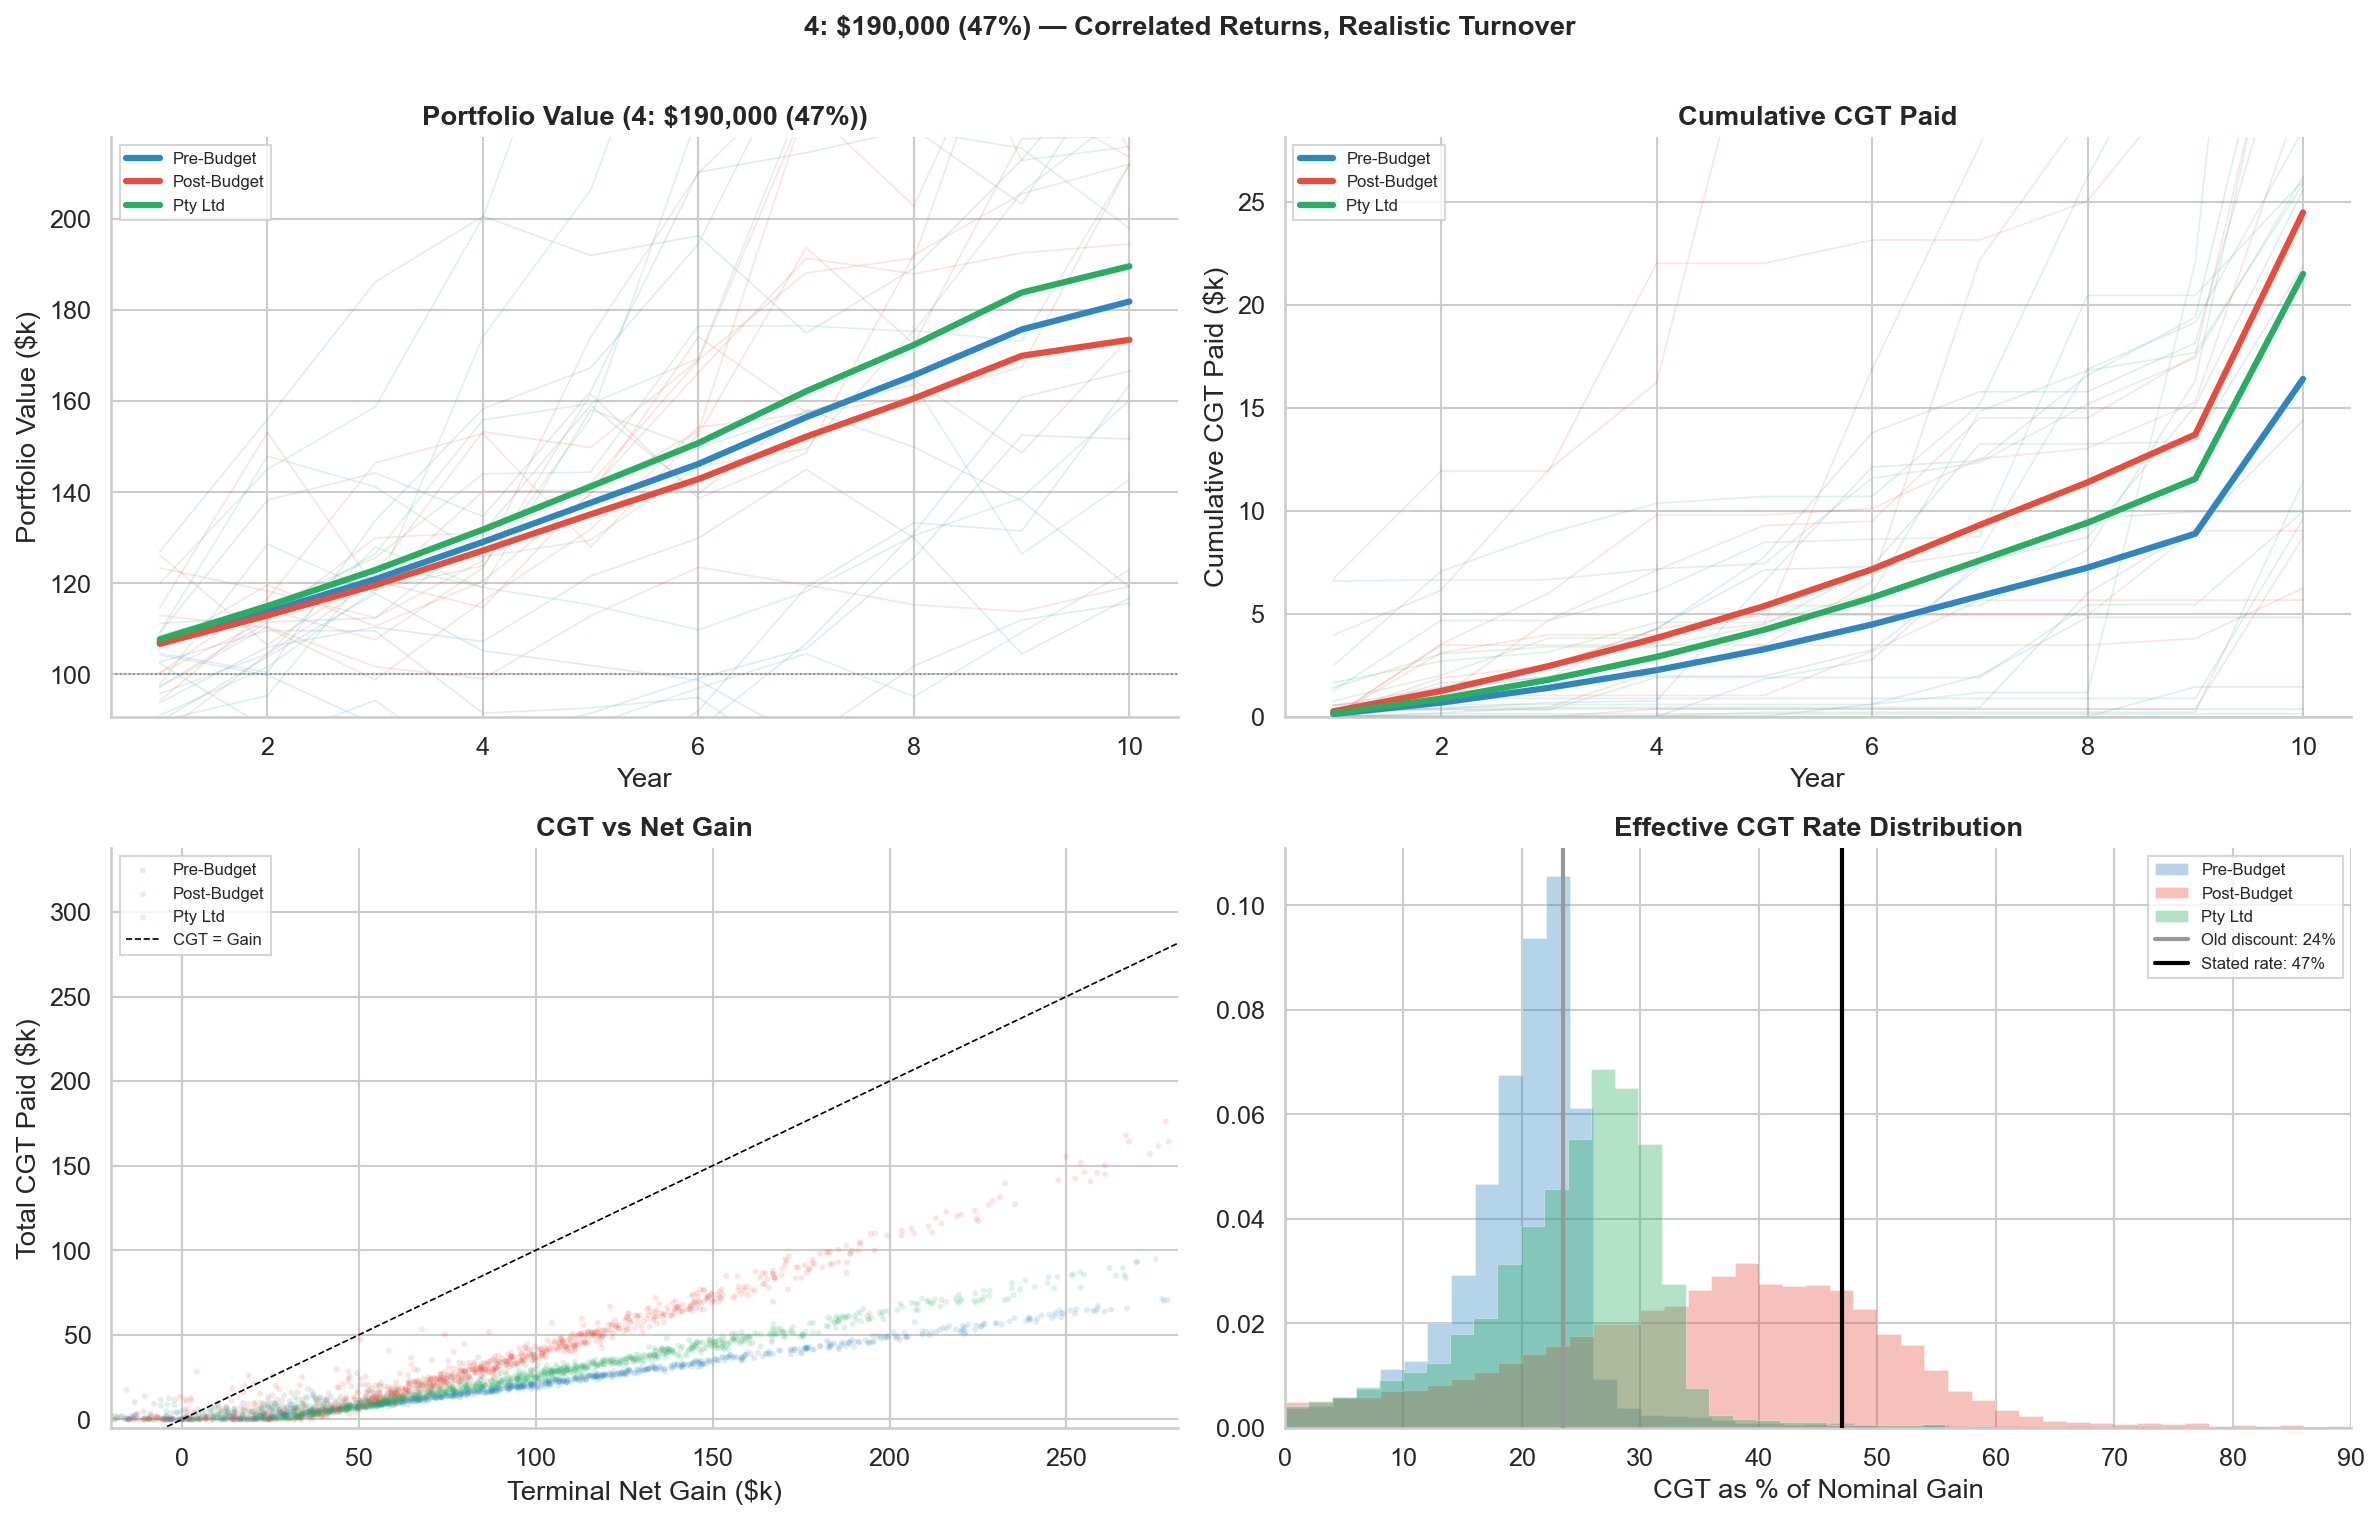

In [10]:
DRILL_BRACKETS = ['3: $135,000 (32%)', '4: $190,000 (47%)']
REF_RATES = [32, 47]

for bi, mr_label in enumerate(DRILL_BRACKETS):
    pf_hist = {sc: all_results[mr_label][sc][6] for sc in SCENARIOS}
    cgt_hist = {sc: all_results[mr_label][sc][7] for sc in SCENARIOS}

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    years_arr = np.arange(1, YEARS + 1)

    # Top-left: portfolio value paths
    ax = axes[0, 0]
    for i, sc in enumerate(SCENARIOS):
        m = np.median(pf_hist[sc], axis=0) / 1000
        ax.plot(years_arr, m, color=COLS[i], lw=3, label=sc, zorder=10)
        picks = rng.choice(N_SIMS, size=10, replace=False)
        for j in picks:
            ax.plot(years_arr, pf_hist[sc][j] / 1000,
                    color=COLS[i], alpha=0.15, lw=0.8)
    ax.axhline(INITIAL / 1000, color='gray', lw=0.8, ls=':')
    all_med = np.concatenate([np.median(pf_hist[sc], axis=0) for sc in SCENARIOS]) / 1000
    ax.set_ylim(all_med.min() * 0.85, all_med.max() * 1.15)
    ax.set_ylabel('Portfolio Value ($k)'); ax.set_xlabel('Year')
    ax.set_title(f'Portfolio Value ({mr_label})', fontweight='bold')
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    for i, sc in enumerate(SCENARIOS):
        m = np.median(cgt_hist[sc], axis=0) / 1000
        ax.plot(years_arr, m, color=COLS[i], lw=3, label=sc, zorder=10)
        picks = rng.choice(N_SIMS, size=10, replace=False)
        for j in picks:
            ax.plot(years_arr, cgt_hist[sc][j] / 1000,
                    color=COLS[i], alpha=0.15, lw=0.8)
    all_cgt = np.concatenate([np.median(cgt_hist[sc], axis=0) for sc in SCENARIOS]) / 1000
    ax.set_ylim(0, all_cgt.max() * 1.15)
    ax.set_ylabel('Cumulative CGT Paid ($k)'); ax.set_xlabel('Year')
    ax.set_title('Cumulative CGT Paid', fontweight='bold')
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    for i, sc in enumerate(SCENARIOS):
        wealth, _, pf, cgt, _, _, _, _, _ = all_results[mr_label][sc]
        net_gain = pf - INITIAL if sc != 'Pty Ltd' else wealth - INITIAL
        n_show = min(1000, N_SIMS)
        idx = rng.choice(N_SIMS, size=n_show, replace=False)
        ax.scatter(net_gain[idx] / 1000, cgt[idx] / 1000,
                   alpha=0.15, s=8, color=COLS[i], label=sc, edgecolors='none')
    all_net = np.concatenate([all_results[mr_label][sc][2] - INITIAL for sc in SCENARIOS])
    xlim = np.percentile(all_net / 1000, 98)
    ax.set_xlim(-20, xlim); ax.set_ylim(-5, xlim * 1.2)
    ax.plot([-20, xlim], [-20, xlim], 'k--', lw=0.8, label='CGT = Gain')
    ax.set_xlabel('Terminal Net Gain ($k)'); ax.set_ylabel('Total CGT Paid ($k)')
    ax.set_title('CGT vs Net Gain', fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')

    ax = axes[1, 1]
    ref_rate = REF_RATES[bi]
    for i, sc in enumerate(SCENARIOS):
        cgt = all_results[mr_label][sc][3]
        pf = all_results[mr_label][sc][2]
        nom_gain = np.maximum(pf - INITIAL, 1e-9)
        eff_cgt = cgt / nom_gain
        mask = (eff_cgt > 0) & (eff_cgt < 1.0)
        ax.hist(eff_cgt[mask] * 100, bins=50, color=COLS[i], alpha=0.35,
                label=sc, density=True, histtype='stepfilled', linewidth=0.5)
    ax.axvline(ref_rate * 0.5, color='#999999', lw=2, ls='-', zorder=10,
               label=f'Old discount: {ref_rate*0.5:.0f}%')
    ax.axvline(ref_rate, color='black', lw=2, ls='-', zorder=10,
               label=f'Stated rate: {ref_rate}%')
    ax.set_xlim(0, 90)
    ax.set_xlabel('CGT as % of Nominal Gain')
    ax.set_title('Effective CGT Rate Distribution', fontweight='bold')
    ax.legend(fontsize=8)

    plt.suptitle(f'{mr_label} — Correlated Returns, Realistic Turnover', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'output/archetype{bi+3}_paths.png', bbox_inches='tight')
    if not IN_JUPYTER:
        plt.close()

## 4. All Archetypes Box Plots

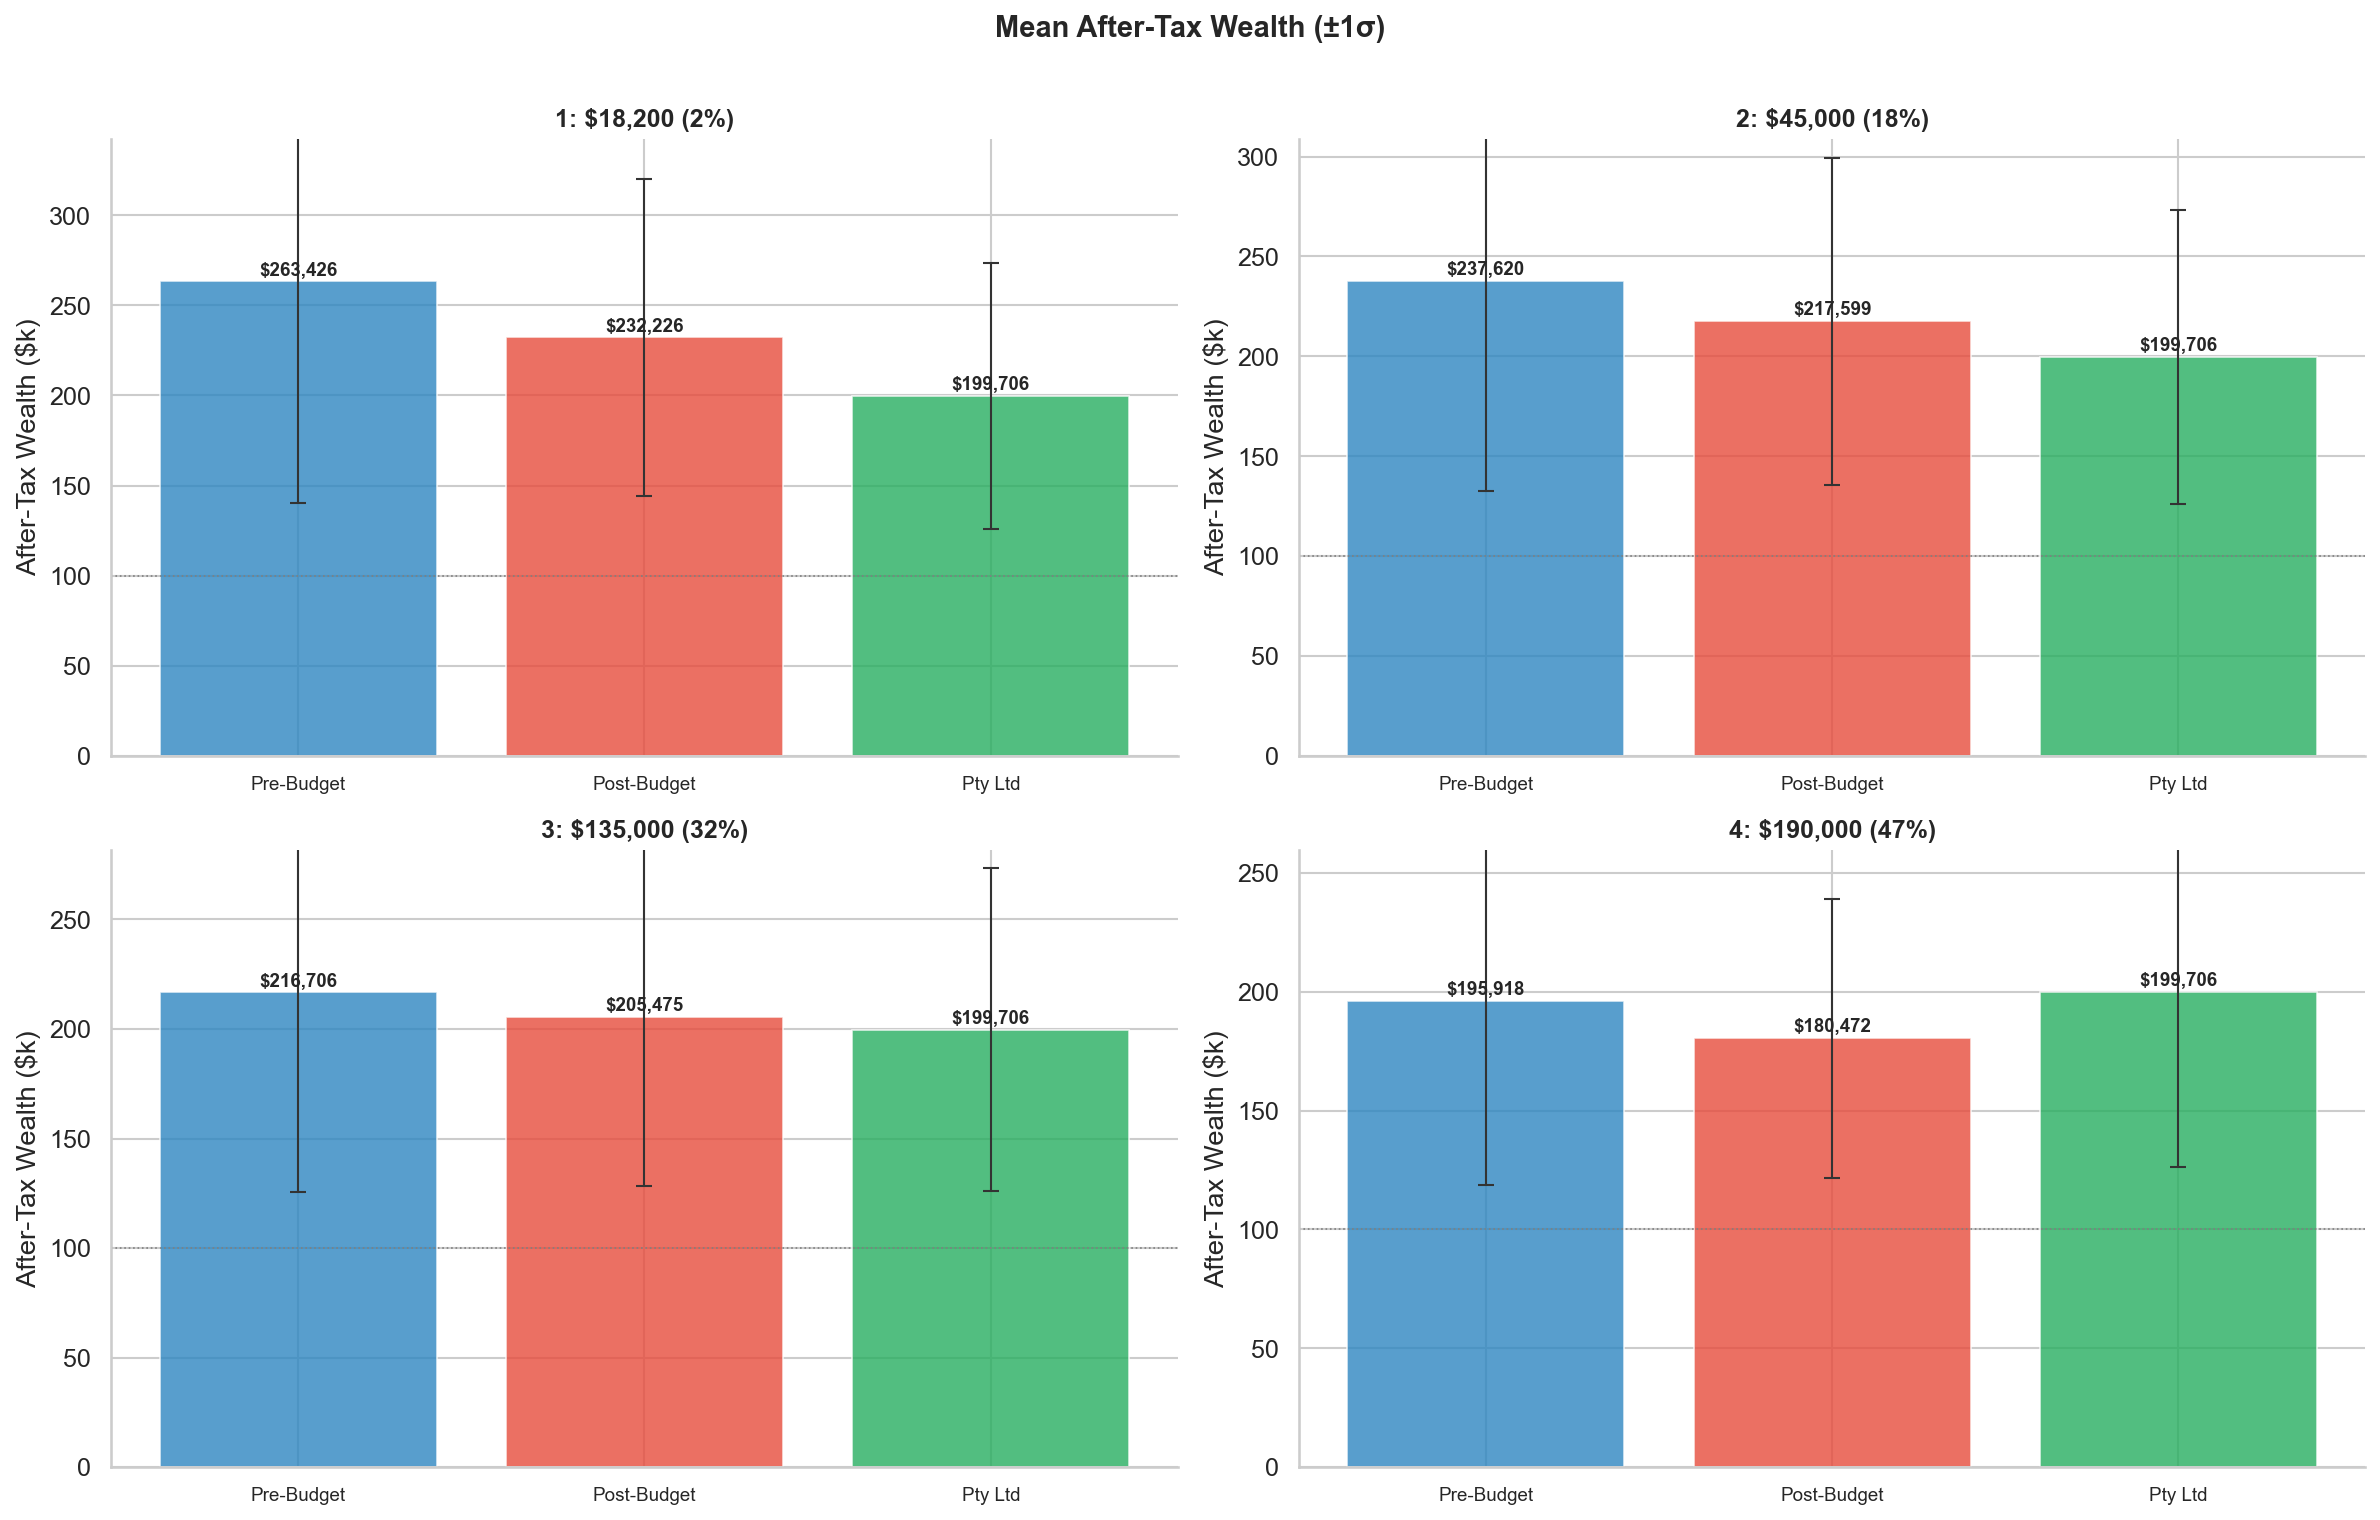

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (arch_label, arch) in enumerate(ARCHETYPES.items()):
    means = []; errs = []
    for sc in SCENARIOS:
        wealth = all_results[arch_label][sc][0]
        means.append(wealth.mean() / 1000)
        errs.append(wealth.std() / 1000)

    ax = axes[idx]
    x = np.arange(len(SCENARIOS))
    bars = ax.bar(x, means, color=COLS, alpha=0.8, edgecolor='white', linewidth=0.8)
    ax.errorbar(x, means, yerr=errs, fmt='none', ecolor='#333333', capsize=4, lw=1)
    # Value labels
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'${mean*1000:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(SCENARIOS, fontsize=9)
    ax.axhline(INITIAL / 1000, color='gray', lw=0.8, ls=':')
    ax.set_title(arch_label, fontweight='bold', fontsize=12)
    ax.set_ylabel('After-Tax Wealth ($k)')
    ax.set_ylim(0, max(means) * 1.3)

plt.suptitle('Mean After-Tax Wealth (±1σ)', fontweight='bold', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('output/all_archetypes_bars.png', bbox_inches='tight')
if not IN_JUPYTER:
    plt.close()

## 5. Sensitivity: Time Horizon

Does the ranking change with investment horizon? Tests 5 through 30 years.


Terminal wealth by horizon (mean $k)
             Archetype         Scenario      5yr    10yr    15yr    20yr    30yr
---------------------- ----------------  ------- ------- ------- ------- -------


       1: $18,200 (2%)       Pre-Budget  $   163k $   266k $   430k $   694k $  1751k


       1: $18,200 (2%)      Post-Budget  $   151k $   234k $   360k $   552k $  1275k


       1: $18,200 (2%)          Pty Ltd  $   140k $   201k $   287k $   409k $   815k


      2: $45,000 (18%)       Pre-Budget  $   154k $   240k $   369k $   567k $  1302k


...

     3: $135,000 (32%)      Post-Budget  $   142k $   207k $   300k $   432k $   882k


     3: $135,000 (32%)          Pty Ltd  $   140k $   201k $   287k $   409k $   815k


     4: $190,000 (47%)       Pre-Budget  $   140k $   197k $   278k $   389k $   747k


     4: $190,000 (47%)      Post-Budget  $   133k $   182k $   248k $   337k $   615k


     4: $190,000 (47%)          Pty Ltd  $   140k $   201k $   287k $   409k $   815k


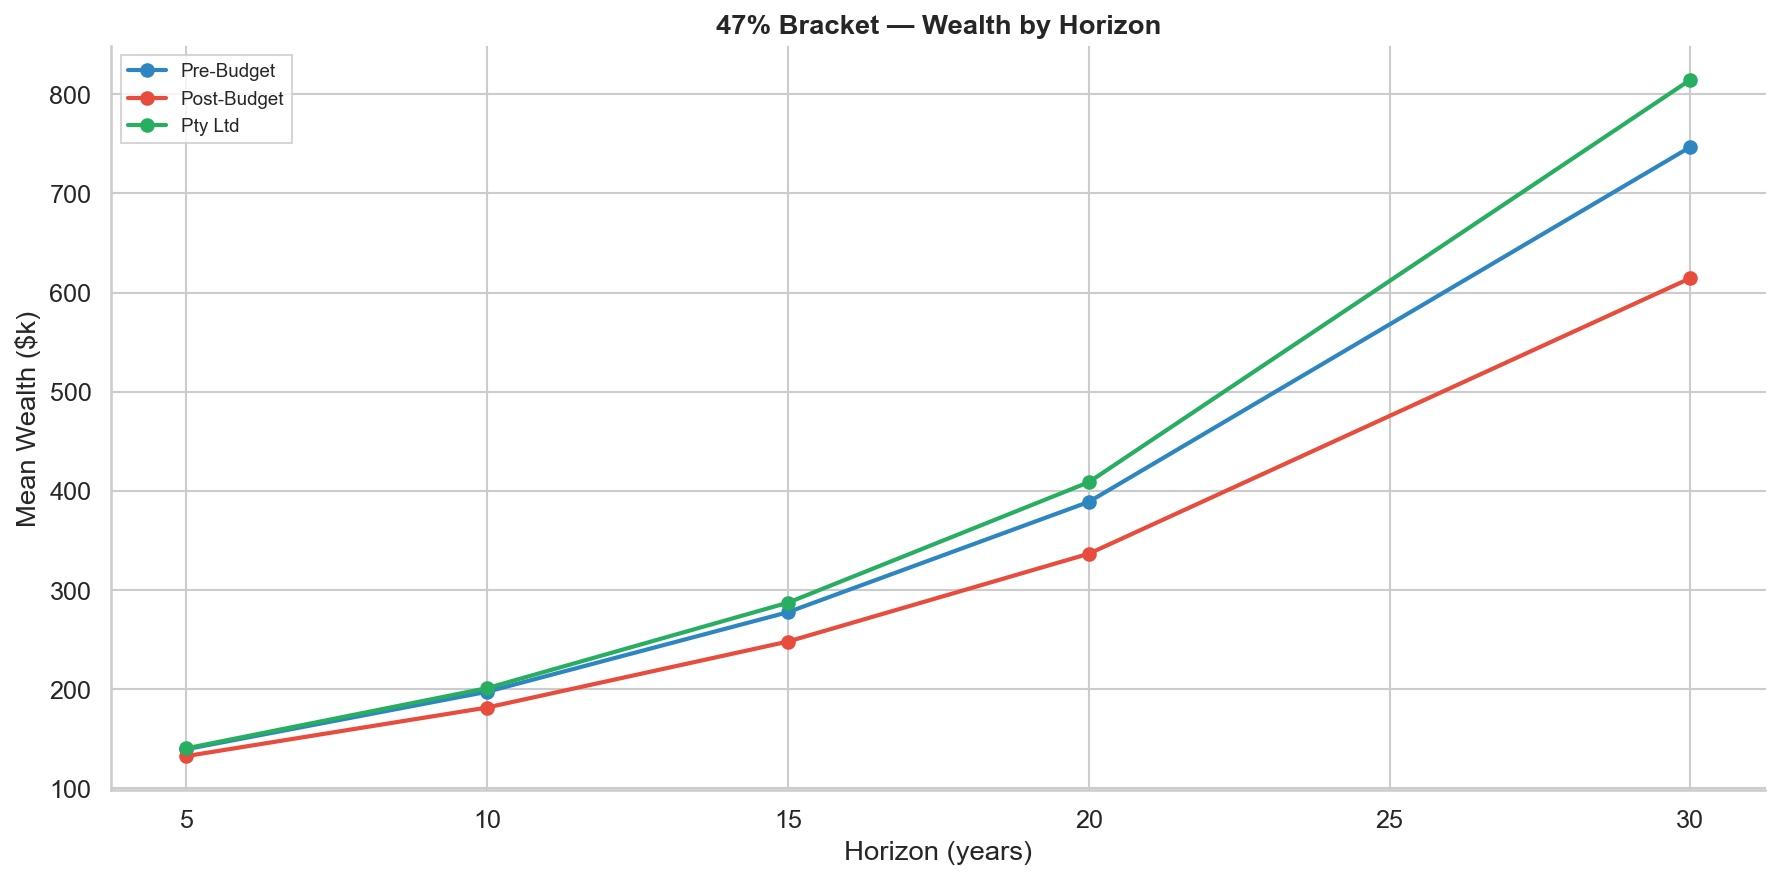

In [12]:
HORIZONS = [5, 10, 15, 20, 30]
_h_saved = _save_globals()

print('\nTerminal wealth by horizon (mean $k)')
print(f'{"Archetype":>22s} {"Scenario":>16s}  {"5yr":>7s} {"10yr":>7s} {"15yr":>7s} {"20yr":>7s} {"30yr":>7s}')
print(f'{"-"*22:>22s} {"-"*16:>16s}  {"-"*7:>7s} {"-"*7:>7s} {"-"*7:>7s} {"-"*7:>7s} {"-"*7:>7s}')

for arch_label, arch in ARCHETYPES.items():
    mr = arch['mr']
    for sc in SCENARIOS:
        vals = []
        for y in HORIZONS:
            _regenerate_shared(y, S_SIMS)
            r = simulate(mr, sc)
            vals.append(r[0].mean() / 1000)
        print(f'{arch_label:>22s} {sc:>16s}  ' + ' '.join(f'${v:>6.0f}k' for v in vals))

horizon_data = {}
for arch_label, arch in ARCHETYPES.items():
    mr = arch['mr']
    horizon_data[arch_label] = {}
    for sc in SCENARIOS:
        vals = []
        for y in HORIZONS:
            _regenerate_shared(y, S_SIMS)
            r = simulate(mr, sc)
            vals.append(r[0].mean() / 1000)
        horizon_data[arch_label][sc] = vals

_restore_globals(_h_saved)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for i, sc in enumerate(SCENARIOS):
    ax.plot(HORIZONS, horizon_data['4: $190,000 (47%)'][sc],
            'o-', color=COLS[i], lw=2, markersize=6, label=sc)
ax.set_xlabel('Horizon (years)'); ax.set_ylabel('Mean Wealth ($k)')
ax.set_title('47% Bracket — Wealth by Horizon', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('output/horizon_sensitivity.png', bbox_inches='tight')
if not IN_JUPYTER:
    plt.close()